# Анализ A/B-теста страницы дебетовой карты

Проверяю, повлияло ли новое сообщение о кешбэке на число заявок.
Смотрю качество данных, конверсии, доверительный интервал и результат теста.
Это учебная работа по продуктовой аналитике.

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency

ALPHA = 0.05


## 1. Загрузка и проверка данных

In [2]:
events = pd.read_csv("data/ab_test_events.csv")
events["date"] = pd.to_datetime(events["date"])
print(events.shape)

checks = pd.Series({
    "rows": len(events),
    "unique_users": events["id"].nunique(),
    "duplicate_user_ids": events["id"].duplicated().sum(),
    "missing_values": events.isna().sum().sum(),
    "experiment_days": events["date"].nunique(),
})
display(checks.to_frame("value"))
display(events.head())

(94778, 4)


,value
rows,94778
unique_users,94778
duplicate_user_ids,0
missing_values,0
experiment_days,93


,date,id,group,converted
0,2023-08-01,5030836,control,0
1,2023-08-01,5091425,control,0
2,2023-08-01,5106537,control,0
3,2023-08-01,4556522,control,0
4,2023-08-01,4002917,control,0


In [3]:
groups = events.groupby("group")
group_checks = groups["id"].nunique().to_frame("users")
group_checks["first_date"] = groups["date"].min()
group_checks["last_date"] = groups["date"].max()
group_checks["converted_users"] = groups["converted"].sum()
display(group_checks)

,users,first_date,last_date,converted_users
group,,,,
control,47330,2023-08-01,2023-11-01,4922
test,47448,2023-08-01,2023-11-01,5674


## 2. Сравнение конверсий

In [4]:
grouped = events.groupby("group")["converted"]
summary = grouped.size().to_frame("users")
summary["conversions"] = grouped.sum()
summary["conversion_rate"] = grouped.mean()
summary["conversion_rate_pct"] = (summary["conversion_rate"] * 100).round(2)

control_rate = summary.loc["control", "conversion_rate"]
test_rate = summary.loc["test", "conversion_rate"]
absolute_change = test_rate - control_rate
relative_change = test_rate / control_rate - 1

display(summary)
print(f"Абсолютное изменение: {absolute_change:.2%}")
print(f"Относительное изменение: {relative_change:.2%}")

,users,conversions,conversion_rate,conversion_rate_pct
group,,,,
control,47330,4922,0.103993,10.40
test,47448,5674,0.119584,11.96


Абсолютное изменение: 1.56%
Относительное изменение: 14.99%


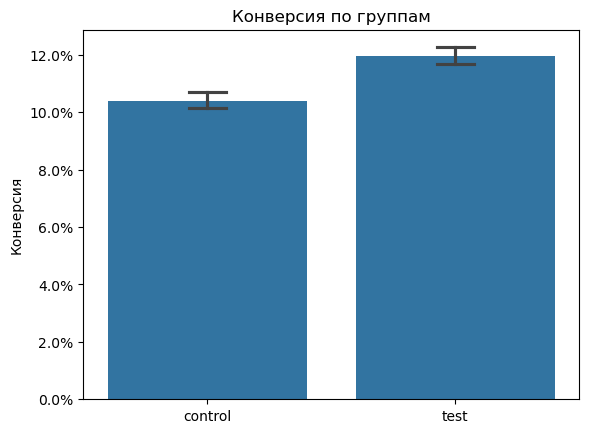

In [5]:
ax = sns.barplot(
    data=events,
    x="group",
    y="converted",
    errorbar=("ci", 95),
    capsize=0.15,
)
ax.set(title="Конверсия по группам", xlabel="", ylabel="Конверсия")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
plt.show()

## 3. Проверка различий

In [6]:
contingency = pd.crosstab(events["group"], events["converted"])
chi_square, p_value, degrees, expected = chi2_contingency(contingency)

pooled_rate = events["converted"].mean()
standard_error = np.sqrt(
    pooled_rate * (1 - pooled_rate)
    * (1 / summary.loc["control", "users"] + 1 / summary.loc["test", "users"])
)
margin = 1.96 * standard_error
confidence_interval = (absolute_change - margin, absolute_change + margin)

print(f"Статистика хи-квадрат: {chi_square:.3f}")
print(f"P-значение: {p_value:.4f}")
print(
    "95% доверительный интервал абсолютного изменения: "
    f"[{confidence_interval[0]:.2%}, {confidence_interval[1]:.2%}]"
)
print(f"Статистическая значимость на уровне 5%: {p_value < ALPHA}")

Статистика хи-квадрат: 57.841
P-значение: 0.0000
95% доверительный интервал абсолютного изменения: [1.16%, 1.96%]
Статистическая значимость на уровне 5%: True


## 4. Конверсия по дням

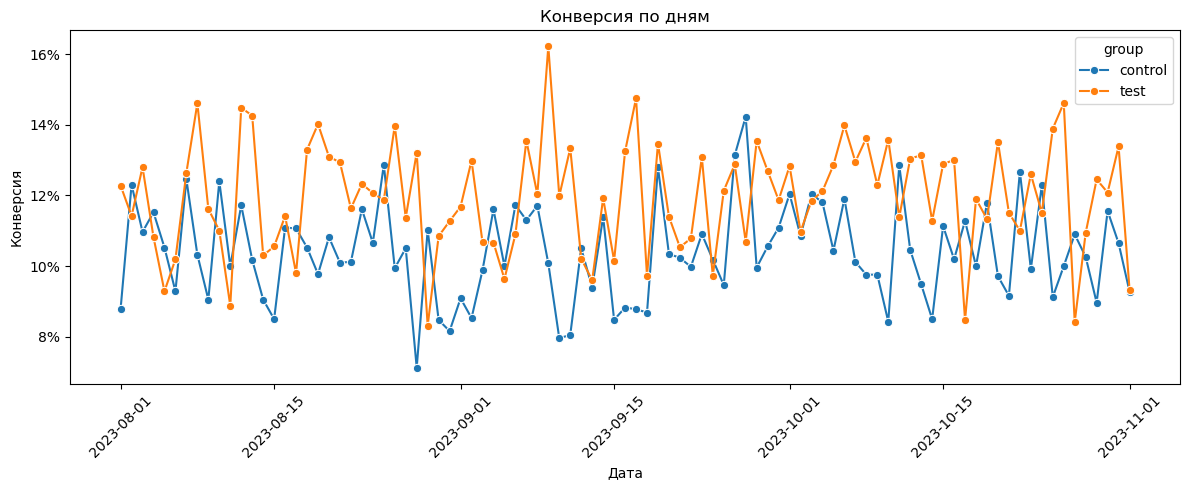

In [7]:
daily_grouped = events.groupby(["date", "group"])["converted"]
daily = daily_grouped.size().to_frame("users")
daily["conversions"] = daily_grouped.sum()
daily["conversion_rate"] = daily_grouped.mean()
daily = daily.reset_index()

plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=daily,
    x="date",
    y="conversion_rate",
    hue="group",
    marker="o",
)
ax.set(title="Конверсия по дням", xlabel="Дата", ylabel="Конверсия")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Решение

In [8]:
if p_value < ALPHA and confidence_interval[0] > 0:
    decision = "Тестовая версия повысила конверсию. Ее можно запускать."
elif p_value < ALPHA and confidence_interval[1] < 0:
    decision = "Тестовая версия снизила конверсию. Запускать ее не стоит."
else:
    decision = (
        "Данных недостаточно, чтобы подтвердить изменение конверсии. "
        "Оставляем текущую версию или собираем больше данных."
    )

print(decision)

Тестовая версия повысила конверсию. Ее можно запускать.
